In [172]:
import sys
import os
import json
import torch
import gpytorch
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split


In [173]:

try:
    current_dir = os.getcwd()
except:
    current_dir = os.path.dirname(os.path.abspath(__file__))

training_data_dir = os.path.join(current_dir, 'training_data')
model_dir = os.path.join(current_dir, 'model')
sys.path.insert(0,str(training_data_dir))
sys.path.insert(0,str(model_dir))

from simdata_mush_dirc_icc import  *
from model import *

def set_seed(seed):
    # Set random seeds for reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    os.environ["PYTHONHASHSEED"] = str(seed)

    # Use deterministic algorithms
    torch.use_deterministic_algorithms(True)

    # This may not exist on macOS if not using GPU or CuDNN
    if torch.backends.mps.is_available():  # MPS = Apple GPU backend
        print("Using Apple Metal Performance Shaders (MPS)")
    elif torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(1234)

Using Apple Metal Performance Shaders (MPS)


The spatial step is 0.0003061224489795918
The time step is 0.000330226858600583


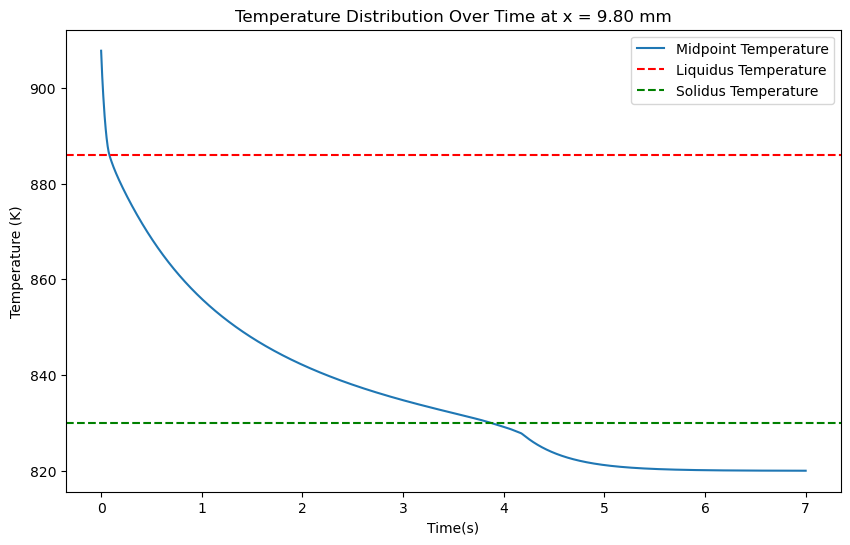

In [174]:
# Data Prep
settings_path_1 = os.path.join(current_dir, 'training_data', 'settings.json')
with open(settings_path_1,'r') as file:
    settings = json.load(file)


heat_data = HT_sim(settings)
alpha = heat_data.alpha_l
tempfield = heat_data.datagen()

heat_data.plot_temp(32)
dt = heat_data.dt
dx = heat_data.dx
# print(heat_data.dx)
# print(dt)
settings_path = os.path.join(current_dir, 'training_data', 'settings.json')
with open(settings_path,'r') as file:
    props = json.load(file)
    

In [175]:
temp_data = tempfield.flatten()

scaler_temp = MinMaxScaler()

temp_scaled = scaler_temp.fit_transform(temp_data.reshape(-1, 1))
print(temp_scaled.max(), temp_scaled.min())
temp_init = props['temp_init']
t_surr = props['t_surr']


1.0 0.0


In [176]:
num_steps = tempfield.shape[0]
numpoints = tempfield.shape[1] 


length = props['length']
time_end = props['time_end']

inp_data = fdd(15e-3, time_end, numpoints, num_steps)
scale_inp = MinMaxScaler()
inp_x = scale_inp.fit_transform(inp_data[:,0].reshape(-1, 1))
inp_y = scale_inp.fit_transform(inp_data[:,1].reshape(-1, 1))
inp_data = np.hstack((inp_x, inp_y))

print(inp_data.shape)
print(temp_scaled.shape)

(1059950, 2)
(1059950, 1)


In [177]:
data_x = torch.tensor(inp_data, dtype=torch.float32)
data_y = torch.tensor(temp_scaled, dtype=torch.float32)
indices = np.arange(len(data_x))

train_x, test_x, train_y, test_y, index_train, index_test = train_test_split(data_x, data_y, indices, test_size=0.2, random_state=42)

subset_size = 1000
subset_indices = np.random.choice(np.arange(len(train_x)), size=subset_size, replace=False)

train_x_subset = train_x[subset_indices]
train_y_subset = train_y[subset_indices].squeeze(-1)

subset_test_indices = np.random.choice(np.arange(len(test_x)), size=subset_size, replace=False)
test_x_subset = test_x[subset_test_indices]
test_y_subset = test_y[subset_test_indices].squeeze(-1)

print("Train subset shape:", train_x_subset.shape, train_y_subset.shape)

Train subset shape: torch.Size([1000, 2]) torch.Size([1000])


In [178]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x_subset, train_y_subset, likelihood)

In [179]:
# train the model

model.train()
likelihood.train()

optimizer = torch.optim.Adam(model.parameters(), lr=0.05)  # Includes GaussianLikelihood parameters
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

num_epochs = 5000
for epoch in range(num_epochs):
    optimizer.zero_grad()
    output = model(train_x_subset)
    loss = -mll(output, train_y_subset)
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item()}')

Epoch 1/5000, Loss: 0.7542487978935242
Epoch 11/5000, Loss: 0.5608702301979065
Epoch 21/5000, Loss: 0.3525550663471222
Epoch 31/5000, Loss: 0.12403301894664764
Epoch 41/5000, Loss: -0.11616424471139908
Epoch 51/5000, Loss: -0.36110395193099976
Epoch 61/5000, Loss: -0.6096393465995789
Epoch 71/5000, Loss: -0.8674024343490601
Epoch 81/5000, Loss: -1.1280415058135986
Epoch 91/5000, Loss: -1.368066430091858
Epoch 101/5000, Loss: -1.6249464750289917
Epoch 111/5000, Loss: -1.8539843559265137
Epoch 121/5000, Loss: -2.0376148223876953
Epoch 131/5000, Loss: -2.2077770233154297
Epoch 141/5000, Loss: -2.327242136001587
Epoch 151/5000, Loss: -2.398892641067505
Epoch 161/5000, Loss: -2.243023633956909
Epoch 171/5000, Loss: -2.25026273727417
Epoch 181/5000, Loss: -2.220107316970825
Epoch 191/5000, Loss: -2.2290549278259277
Epoch 201/5000, Loss: -2.3585355281829834
Epoch 211/5000, Loss: -2.3369734287261963
Epoch 221/5000, Loss: -2.3972043991088867
Epoch 231/5000, Loss: -2.429100513458252
Epoch 241/50

In [180]:
# test the model
model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    
    observed_pred = likelihood(model(test_x_subset))
    mean = scaler_temp.inverse_transform(observed_pred.mean.reshape(-1, 1))
    lower, upper = observed_pred.confidence_region()
    lower = scaler_temp.inverse_transform(lower.reshape(-1, 1))
    upper = scaler_temp.inverse_transform(upper.reshape(-1, 1))


In [181]:
test_y_scaled = scaler_temp.inverse_transform(test_y_subset.reshape(-1, 1))

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(test_y_scaled, mean)
r2 = r2_score(test_y_scaled, mean)
print(f"MSE: {mse:.4f}, R²: {r2:.4f}")


MSE: 0.2029, R²: 0.9991


(1000, 1) (1000, 1) (1000, 1)


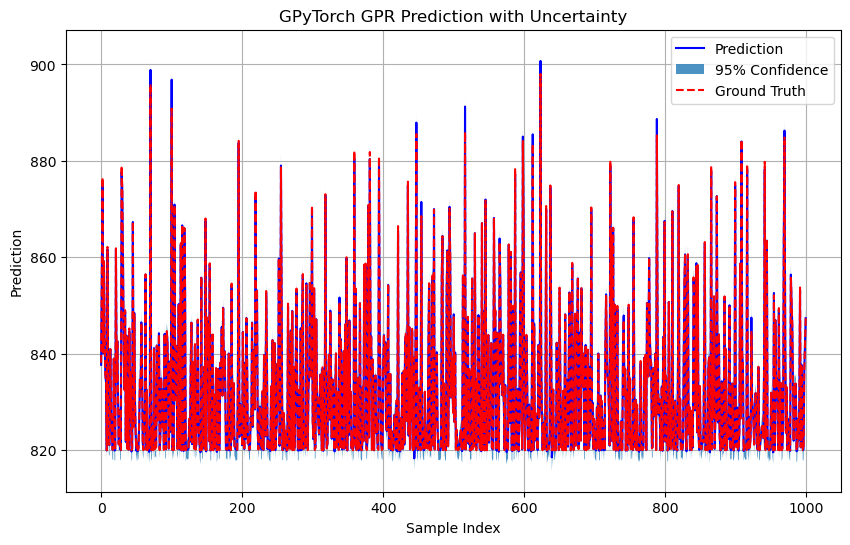

In [182]:
x = range(len(mean))  # or test_x if it's 1D
print(mean.shape, lower.shape, upper.shape)
plt.figure(figsize=(10,6))
plt.plot(x, mean, 'b', label='Prediction')
plt.fill_between(x, lower.squeeze(-1), upper.squeeze(-1), alpha=0.8, label='95% Confidence')
plt.plot(x, test_y_scaled, 'r--', label='Ground Truth')
plt.legend()
plt.title("GPyTorch GPR Prediction with Uncertainty")
plt.xlabel("Sample Index")
plt.ylabel("Prediction")
plt.grid()
plt.show()

In [183]:
# plot the input to prediction and generate 2D plot

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    total_x = torch.tensor(data_x, dtype=torch.float32)
    total_y = torch.tensor(temp_scaled, dtype=torch.float32)
    
    pred_x = model(total_x)
    observed_pred = likelihood(pred_x)
    mean = scaler_temp.inverse_transform(observed_pred.mean.reshape(-1, 1))
    lower, upper = observed_pred.confidence_region()
    lower = scaler_temp.inverse_transform(lower.reshape(-1, 1))
    upper = scaler_temp.inverse_transform(upper.reshape(-1, 1))
    total_y_scaled = scaler_temp.inverse_transform(total_y.reshape(-1, 1))
    print(mean.shape, lower.shape, upper.shape)

/var/folders/n6/ghryp_kj2q5bq6_cvyt57x2h0000gn/T/ipykernel_13036/3294471055.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  total_x = torch.tensor(data_x, dtype=torch.float32)


(1059950, 1) (1059950, 1) (1059950, 1)


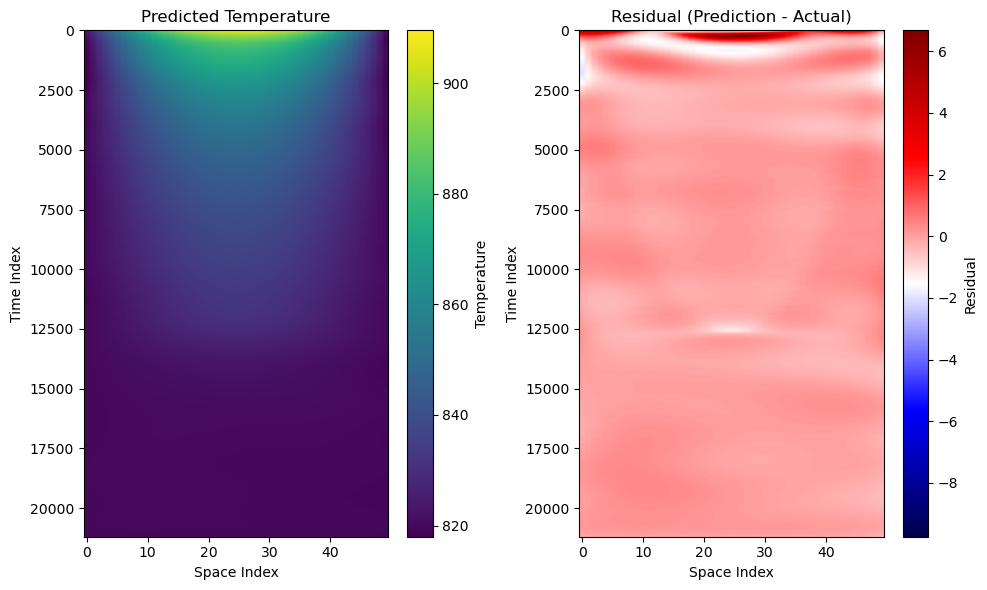

In [184]:
mean = mean.reshape(num_steps, numpoints)
act_temp = total_y_scaled.reshape(num_steps, numpoints)

residual = mean - act_temp

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.imshow(mean, aspect='auto', cmap='viridis')
plt.title('Predicted Temperature')
plt.xlabel('Space Index')
plt.ylabel('Time Index')
plt.colorbar(label='Temperature')

plt.subplot(1, 2, 2)
plt.imshow(residual, aspect='auto', cmap='seismic')
plt.title('Residual (Prediction - Actual)')
plt.xlabel('Space Index')
plt.ylabel('Time Index')
plt.colorbar(label='Residual')

plt.tight_layout()
plt.show()
